https://www.pyquantnews.com/the-pyquant-newsletter/build-a-pairs-trading-strategy-python

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS
import yfinance as yf
import seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
# Download stock data
# symbol_list = ['META', 'AMZN', 'AAPL', 'NFLX', 'GOOG']
symbol_list = [
    'AGQ', 
    'BBY', 
    'CSX', 
    'DAL', 
    'EPP', 
    'EPU', 
    'EWA', 
    'EWD', 
    # 'EWJ', 
    'HEDJ',
    'HPQ', 
    'LMT', 
    'SPY', 
    'STT', 
    'SWKS', 
    'TECL', 
    'THD', 
    'TIP', 
    'WBA', 
    'XOM'
]

start_date = '2016-12-31'
end_date = '2017-03-31'

data = yf.download(
    symbol_list, 
    start=start_date, 
    end=end_date,
    auto_adjust=False
)['Adj Close']

# Function to find cointegrated pairs
def find_cointegrated_pairs(data):
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.columns
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

[*********************100%***********************]  19 of 19 completed


In [3]:
# Find cointegrated pairs
scores, pvalues, pairs = find_cointegrated_pairs(data)

# Create a mask for p-values >= 0.05 (set to None for Plotly)
masked_pvalues = np.where(pvalues < 0.05, pvalues, None)

# %%
# Create heatmap using Plotly
fig = go.Figure(data=go.Heatmap(
    z=masked_pvalues,
    x=symbol_list,
    y=symbol_list,
    colorscale='RdYlGn_r',
    zmin=0,
    zmax=0.05,
    text=pvalues.round(4),  # Display rounded p-values
    texttemplate='%{text}',  # Show text on heatmap
    hoverinfo='x+y+z',  # Show x, y, and z (p-value) on hover
))

# Update layout for better readability
fig.update_layout(
    title='Cointegration P-Values Heatmap (p < 0.05)',
    xaxis_title='Stocks',
    yaxis_title='Stocks',
    xaxis=dict(tickangle=45),
    yaxis=dict(autorange='reversed'),  # Reverse y-axis to match Seaborn's orientation
    width=800,
    height=800
)

# Show the plot
fig.show()

In [4]:
# S1 = data['LMT']
# S2 = data['HPQ']

# S1 = data['HEDJ']
# S2 = data['EWA']

# S1 = data['TECL']
# S2 = data['EPP']

# S1 = data['WBA']
# S2 = data['CSX']

## S1 = data['SWKS']
## S2 = data['XOM']

## NOT WORKING
# S1 = data['XOM']
# S2 = data['SWKS']

# S1 = data['CSX']
# S2 = data['BBY']

S1 = data['TIP']
S2 = data['BBY']

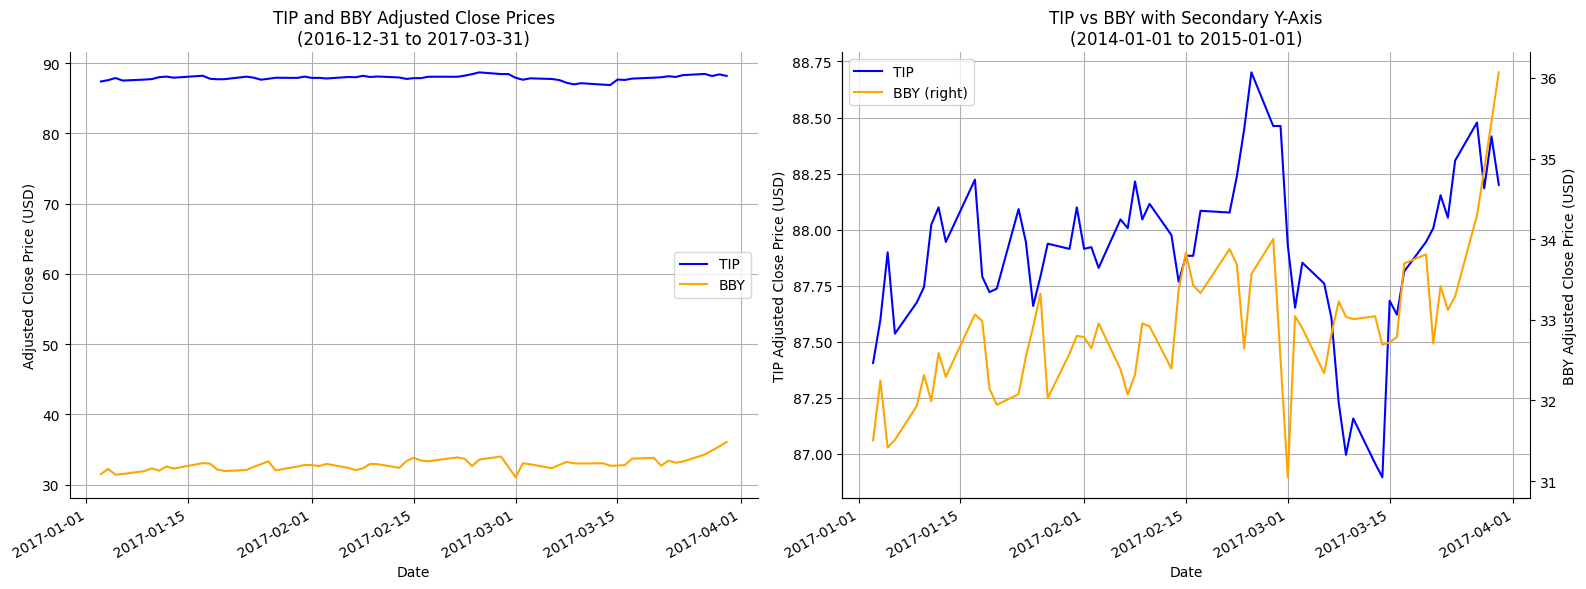

In [5]:
# Create a figure with 2 rows and 1 column of subplots
fig, (ax1, ax2) = plt.subplots(1, 
                               2,
                               figsize=(16, 6), 
                               sharex=True
                               )

S1.plot(label=S1.name, color='blue', ax=ax1)
S2.plot(label=S2.name, color='orange', ax=ax1)
ax1.set_title(f'{S1.name} and {S2.name} Adjusted Close Prices\n({start_date} to {end_date})')
ax1.set_xlabel('Date')
ax1.set_ylabel('Adjusted Close Price (USD)')
ax1.legend()
ax1.grid(True)
sns.despine(ax=ax1)

# Subplot 2: Secondary y-axis (dual scale)
S1.plot(label=S1.name, color='blue', ax=ax2)
S2.plot(label=S2.name, color='orange', ax=ax2, secondary_y=True)
ax2.set_title(f'{S1.name} vs {S2.name} with Secondary Y-Axis\n(2014-01-01 to 2015-01-01)')
ax2.set_xlabel('Date')
ax2.set_ylabel(f'{S1.name} Adjusted Close Price (USD)')
ax2.right_ax.set_ylabel(f'{S2.name} Adjusted Close Price (USD)')

# Combine legends from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2.right_ax.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax2.grid(True)
sns.despine(ax=ax2)
sns.despine(ax=ax2.right_ax, right=False)

plt.tight_layout()

In [6]:
# Spread modeling
S1_reg = sm.add_constant(S1)
results = sm.OLS(S2, S1_reg).fit()
print(results.summary())
intercept = results.params.iloc[0]
hedge_ratio = results.params.iloc[1]
print(f'Hedge Ratio: {hedge_ratio}, Intercept: {intercept}')
estimate = hedge_ratio * S1 + intercept
spread = S2 - estimate

                            OLS Regression Results                            
Dep. Variable:                    BBY   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     6.321
Date:                Fri, 26 Sep 2025   Prob (F-statistic):             0.0147
Time:                        00:54:30   Log-Likelihood:                -75.790
No. Observations:                  61   AIC:                             155.6
Df Residuals:                      59   BIC:                             159.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -33.8399     26.549     -1.275      0.2

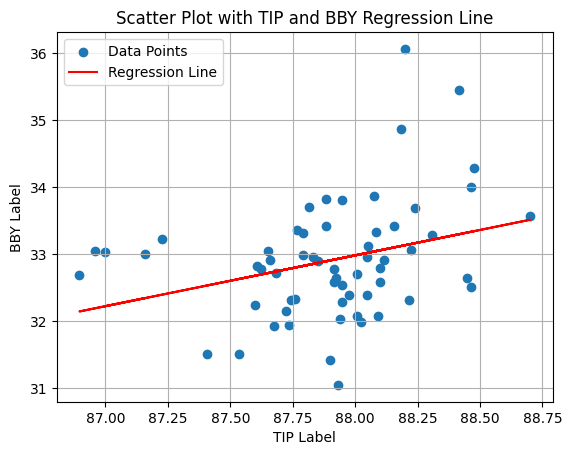

In [7]:
# plot S1 and S2 scatter plot with regression line
# Create the scatter plot
plt.scatter(S1, S2, label='Data Points')

# Plot the regression line
plt.plot(S1, hedge_ratio*S1 + intercept, color='red', label='Regression Line')

# Add labels and title
plt.xlabel(f'{S1.name} Label')
plt.ylabel(f'{S2.name} Label')
plt.title(f'Scatter Plot with {S1.name} and {S2.name} Regression Line')
plt.legend() # Show the legend for labels
plt.grid(True)
plt.show()

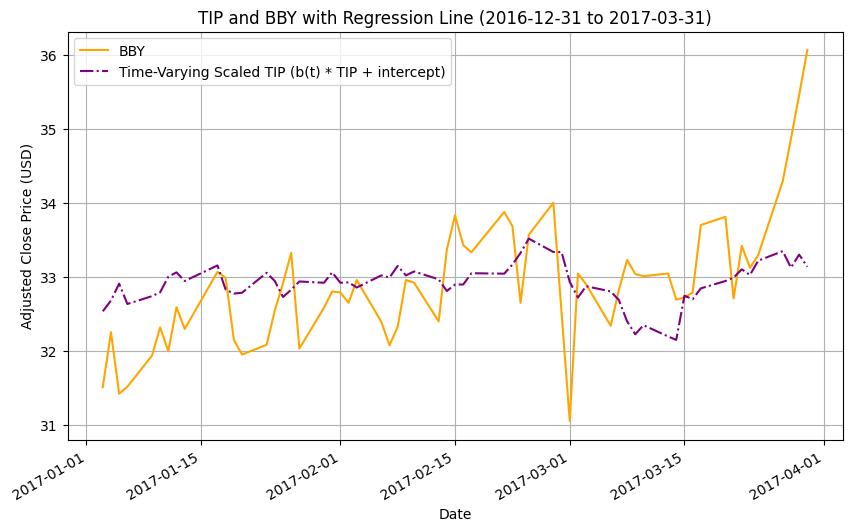

In [8]:
#plot S1 and S2 with linear regression line
plt.figure(figsize=(10, 6))
# S1.plot(label=S1.name, color='blue')
S2.plot(label=S2.name, color='orange')
plt.plot(S1.index, estimate.values,
              label=f'Time-Varying Scaled {S1.name} (b(t) * {S1.name} + intercept)',
              color='purple', linestyle='-.')
plt.title(f'{S1.name} and {S2.name} with Regression Line ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

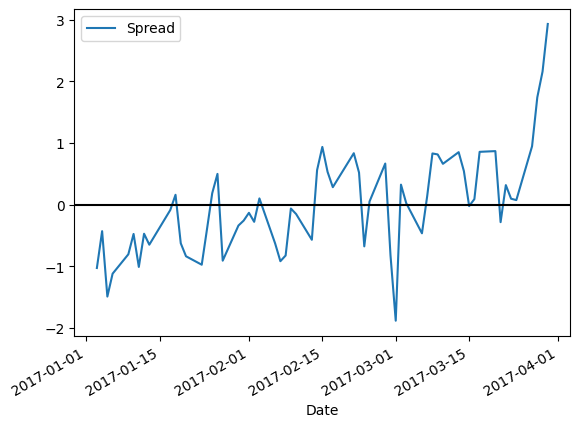

In [9]:
# Plot the spread
spread.plot()
plt.axhline(spread.mean(), color='black')
plt.legend(['Spread'])
plt.show()

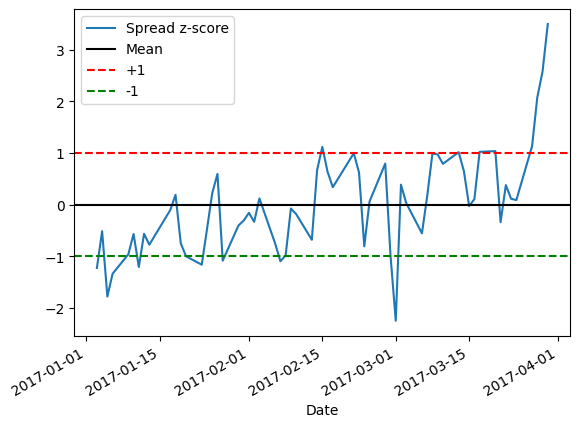

In [10]:
# Calculate and plot z-score
def zscore(series):
    return (series - series.mean()) / np.std(series)

zscore(spread).plot()
plt.axhline(zscore(spread).mean(), color='black')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Spread z-score', 'Mean', '+1', '-1'])
plt.show()

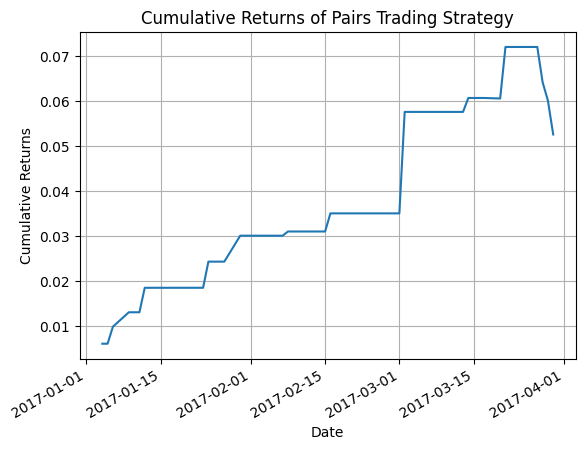

In [11]:
# Create trading signals
trades = pd.concat([zscore(spread), spread], axis=1)
trades.columns = ["signal", "position"]

# Add long and short positions
trades["side"] = 0.0
trades.loc[trades.signal <= -1, "side"] = 1
trades.loc[trades.signal >= 1, "side"] = -1

# Calculate and plot returns
# Approximate capital for the pair (dollars for 1 share of S2 and hedge_ratio shares of S1)
capital = S2 + hedge_ratio * S1

# Daily pnl = side (from previous period) * change in spread
pnl = trades.side.shift(1) * spread.diff()

# Normalize to get percentage returns
returns = pnl / capital.shift(1)

# Plot cumulative returns
returns.cumsum().plot()
plt.title('Cumulative Returns of Pairs Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True)
plt.show()